In [121]:
from math import *
import numpy as np
from scipy.linalg import expm
from qutip import *
import random
from scipy import optimize
from datetime import datetime
import time
import pandas as pd
from scipy.linalg import fractional_matrix_power
from sklearn.feature_extraction.text import CountVectorizer
from scipy import linalg
from qutip import bloch
import matplotlib.pyplot as plt

In [122]:
# complex number
j = (-1)**0.5
 

# pauli matrix
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -j], [j, 0]])
sz = np.array([[1, 0], [0, -1]])
s0 = np.array([[1, 0], [0, 1]])

# Detunning Factor
d0 = 0.15
v0 = 0.02

In [123]:
def Rx(theta):
    return np.matrix([[cos(theta/2),     -1j*sin(theta/2)],
                    [-1j*sin(theta/2),     cos(theta/2)]])

def Rz(phi): # Rz는 사용하지 않음. 해밀토니안에 의한 회전으로만 컨트롤
    return np.matrix([[cos(phi/2)-1j*sin(phi/2),       0],
                     [0,                          cos(phi/2)+1j*sin(phi/2)]])

In [124]:
def unitary(dt, choice) :
    choice_list = [0,1,-1] # x-rotiation 방향 선택
    Ham = (d0*sz+v0*choice_list[choice]*sx)
    eigvals = np.linalg.eigh(Ham)[0]
    eigvecs = 1*np.linalg.eigh(Ham)[1]
    E = np.diag(eigvals)
    U_H = eigvecs.conj().T
    U_e = U_H.conj().T @ expm(-j*E*dt) @ U_H
    return U_e

In [125]:
def state_fidelity(rho_1, rho_2): #fidelity
        if np.shape(rho_1) != np.shape(rho_2):
            print("Dimensions of two states do not match.")
            return 0
        else:
            sqrt_rho_1 = fractional_matrix_power(rho_1, 1 / 2)
            fidelity = np.trace(fractional_matrix_power(sqrt_rho_1 @ rho_2 @ sqrt_rho_1, 1 / 2)) ** 2
            return np.real(fidelity)

In [126]:
init_wave = np.array([[1],[0]])
irho_init = np.kron(init_wave,init_wave.conj().T)

In [127]:
target_theta, target_phi , dt , combi = 3.042102479, 1.896262805 , 10.41151417 ,	[1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]
print(type(combi))
target_U = Rz(target_phi) @ Rx(target_theta)
irho_target = target_U @ irho_init @target_U.conj().T

<class 'list'>


In [128]:
temp = combi.copy()

In [129]:
combination = []
print(type(combi))
print(combination,combi)

dt = dt/1

<class 'list'>
[] [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]


In [130]:
# for i in range(len(combi)):
#     for j in range(3):
#         combination.append(combi[i])

# combi = combination.copy()

[[ 1.00000000e+00+1.51350592e-19j -2.77555756e-17+2.16840434e-19j]
 [-2.77555756e-17-2.16840434e-19j  1.00000000e+00-1.58968881e-19j]]
[[-4.75164426e-03-0.99121671j  1.69422830e-21-0.13216223j]
 [-1.64824083e-20-0.13216223j -4.75164426e-03+0.99121671j]]
[0.2620028179589872, 0.0012559757855679899, 0.9650662909388015]
[[1.00000000e+00+1.51350592e-19j 2.77555756e-17-2.16840434e-19j]
 [2.77555756e-17+2.16840434e-19j 1.00000000e+00-1.58968881e-19j]]
[[-4.75164426e-03-0.99121671j -1.69422830e-21+0.13216223j]
 [ 1.64824083e-20+0.13216223j -4.75164426e-03+0.99121671j]]
[-0.5056765133587786, -0.00493603792660599, 0.8627090467630992]
[[ 1.00000000e+00+1.51350592e-19j -2.77555756e-17+2.16840434e-19j]
 [-2.77555756e-17-2.16840434e-19j  1.00000000e+00-1.58968881e-19j]]
[[-4.75164426e-03-0.99121671j  1.69422830e-21-0.13216223j]
 [-1.64824083e-20-0.13216223j -4.75164426e-03+0.99121671j]]
[0.7139742274585874, 0.0107827376272041, 0.7000889479874502]
[[1.00000000e+00+1.51350592e-19j 2.77555756e-17-2.168

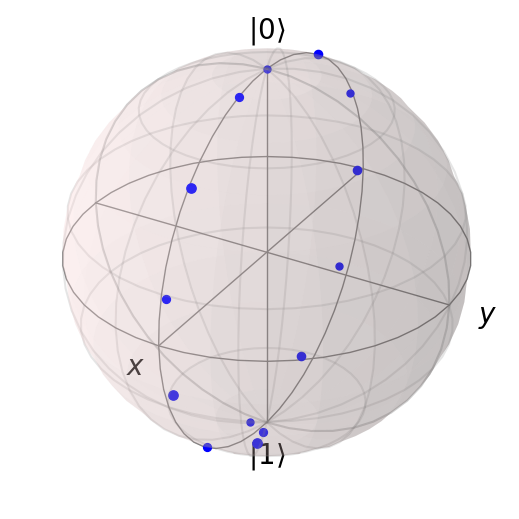

In [131]:

b = Bloch()
irho_mid = np.matrix(irho_init)
#irho_mid = (irho_init)
b.add_points([0,0,1],'m')
for i in temp:
    instant_U = unitary(dt,i)
    print((instant_U @ instant_U.conj().T))
    print(instant_U)
    irho_mid = (instant_U @ irho_mid @ instant_U.conj().T)
    point = [np.trace(irho_mid*sx).real,
             np.trace(irho_mid*sy).real,
             np.trace(irho_mid*sz).real]
    b.add_points(point,'m')
    print(point)

irho_mid = np.array(irho_mid)
print(1 - state_fidelity(irho_target,irho_mid))
point = [np.trace(irho_target*sx).real,
         np.trace(irho_target*sy).real,
         np.trace(irho_target*sz).real]
print(type(irho_target),"\n",point)
b.add_points(point,'r')
b.point_marker = ['o']
b.show()
